In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import seaborn as sns

In [4]:
df=pd.read_csv("Loan_approval_data_2025.csv")


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              50000 non-null  object 
 1   age                      50000 non-null  int64  
 2   occupation_status        50000 non-null  object 
 3   years_employed           50000 non-null  float64
 4   annual_income            50000 non-null  int64  
 5   credit_score             50000 non-null  int64  
 6   credit_history_years     50000 non-null  float64
 7   savings_assets           50000 non-null  int64  
 8   current_debt             50000 non-null  int64  
 9   defaults_on_file         50000 non-null  int64  
 10  delinquencies_last_2yrs  50000 non-null  int64  
 11  derogatory_marks         50000 non-null  int64  
 12  product_type             50000 non-null  object 
 13  loan_intent              50000 non-null  object 
 14  loan_amount           

In [6]:
df.head()

,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,CUST100000,40,Employed,17.2,25579,692,5.3,895,10820,0,0,0,Credit Card,Business,600,17.02,0.423,0.023,0.008,1
1,CUST100001,33,Employed,7.3,43087,627,3.5,169,16550,0,1,0,Personal Loan,Home Improvement,53300,14.10,0.384,1.237,0.412,0
2,CUST100002,42,Student,1.1,20840,689,8.4,17,7852,0,0,0,Credit Card,Debt Consolidation,2100,18.33,0.377,0.101,0.034,1
3,CUST100003,53,Student,0.5,29147,692,9.8,1480,11603,0,1,0,Credit Card,Business,2900,18.74,0.398,0.099,0.033,1
4,CUST100004,32,Employed,12.5,63657,630,7.2,209,12424,0,0,0,Personal Loan,Education,99600,13.92,0.195,1.565,0.522,1


In [9]:
df=df.drop(["customer_id"],axis=1)

In [10]:
df.head()

,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,40,Employed,17.2,25579,692,5.3,895,10820,0,0,0,Credit Card,Business,600,17.02,0.423,0.023,0.008,1
1,33,Employed,7.3,43087,627,3.5,169,16550,0,1,0,Personal Loan,Home Improvement,53300,14.10,0.384,1.237,0.412,0
2,42,Student,1.1,20840,689,8.4,17,7852,0,0,0,Credit Card,Debt Consolidation,2100,18.33,0.377,0.101,0.034,1
3,53,Student,0.5,29147,692,9.8,1480,11603,0,1,0,Credit Card,Business,2900,18.74,0.398,0.099,0.033,1
4,32,Employed,12.5,63657,630,7.2,209,12424,0,0,0,Personal Loan,Education,99600,13.92,0.195,1.565,0.522,1


In [11]:
df['occupation_status'].unique()

array(['Employed', 'Student', 'Self-Employed'], dtype=object)

In [12]:
df['age'].unique()

array([40, 33, 42, 53, 32, 44, 29, 41, 37, 18, 28, 22, 38, 24, 52, 35, 36,
       21, 39, 27, 31, 57, 34, 20, 19, 43, 26, 47, 30, 46, 51, 25, 45, 64,
       48, 61, 23, 50, 67, 70, 62, 60, 56, 54, 49, 59, 58, 55, 65, 66, 63,
       68, 69])

In [13]:
df['years_employed'].unique()

array([17.2,  7.3,  1.1,  0.5, 12.5, 13.4, 22.9,  4.2,  5.9,  7. ,  5. ,
        1.3,  0. ,  1. ,  0.4,  5.3,  5.4, 31.3, 16.9,  0.3,  6.8,  2.9,
        6.2, 12.9, 21.5, 10.7,  3.9, 18.7,  4.7,  0.2,  1.2, 19.1,  3.2,
       10. ,  4.6, 17.4,  7.8, 10.8, 19.3,  3.6,  2.1,  8.8,  3.3,  1.8,
        4.1,  1.9,  2.6,  8.3,  7.1, 20.4, 17.3, 14.2, 33.1,  3.8,  5.6,
        8.2,  9. , 11.4,  6.6,  4.8,  2.4, 13.6,  9.7,  8.4, 11.3,  6.4,
       26.6, 10.6, 14.8,  5.2, 16.4, 13.3, 18.4, 21.4,  0.8, 17.5,  9.8,
       38.2,  0.1,  3.4,  9.6,  1.4, 18.1,  2.2, 15.2, 10.5,  3.5,  3.7,
        1.7, 17.8,  6.7, 23.5, 18.5,  1.5, 14.7, 17. ,  4.4,  6.1, 21.9,
       34.1,  6.9,  8.9, 13. , 13.1, 19.2, 11.7,  8.6,  0.7, 11.5, 14.3,
       16.2,  3.1, 15.4, 22.8, 19.9, 12. , 17.7, 19.8, 23.1, 12.4, 18.6,
        6.5, 15.7,  2.3, 20.8,  0.6, 15. ,  7.6,  2.7, 24.4,  9.2,  4.9,
       26.5,  4.5,  9.5, 21.2, 11. , 33.2, 28.5,  1.6,  2.8,  7.4, 25.5,
        2. , 11.2, 15.3, 10.4, 11.1, 23.6, 20.1, 19

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
for col in df.select_dtypes(include='object').columns:
    print(col)
    print(df[col].unique())
    print('-'*30)

occupation_status
['Employed' 'Student' 'Self-Employed']
------------------------------
product_type
['Credit Card' 'Personal Loan' 'Line of Credit']
------------------------------
loan_intent
['Business' 'Home Improvement' 'Debt Consolidation' 'Education' 'Personal'
 'Medical']
------------------------------


In [16]:
df['loan_status'].value_counts()

loan_status
1    27523
0    22477
Name: count, dtype: int64

In [17]:
df['loan_status'].value_counts(normalize=True)*100

loan_status
1    55.046
0    44.954
Name: proportion, dtype: float64

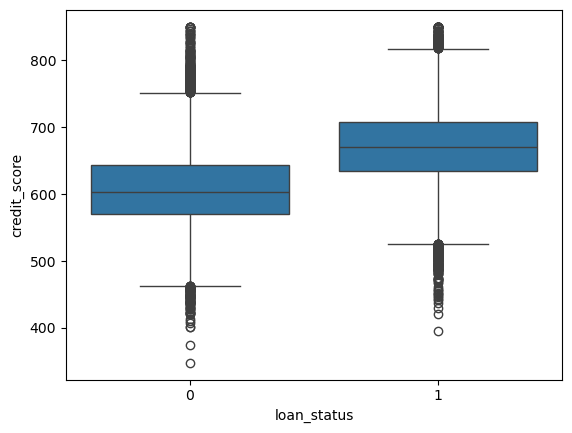

In [20]:
sns.boxplot(x='loan_status', y='credit_score', data=df)
plt.show()

The boxplot shows that approved applicants generally have significantly higher credit scores than rejected applicants. Credit score appears to be a strong predictor of loan approval.

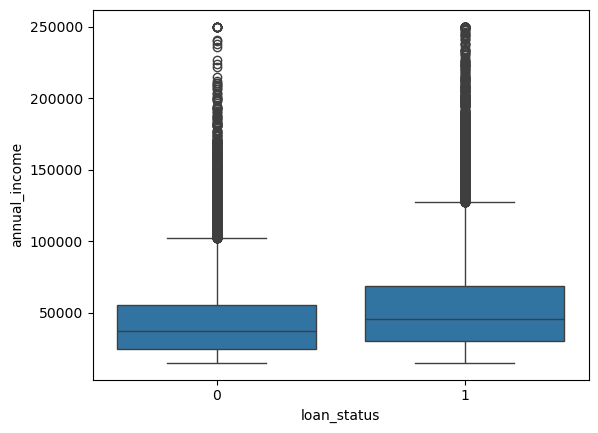

In [21]:
sns.boxplot(x='loan_status', y='annual_income', data=df)
plt.show()


Approved applicants tend to have higher annual incomes compared to rejected applicants. However, the overlap between the distributions indicates that additional factors influence approval decisions.

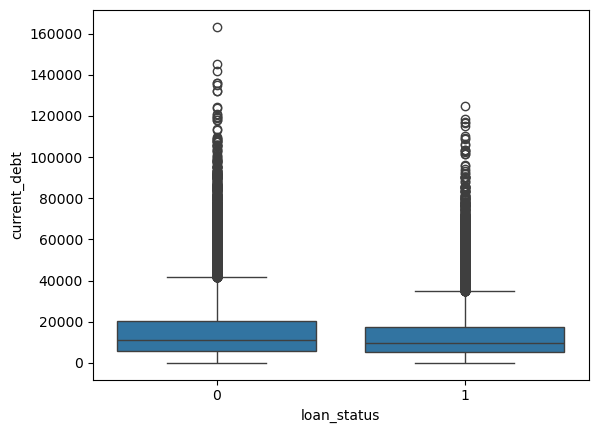

In [22]:
sns.boxplot(x='loan_status', y='current_debt', data=df)
plt.show()

Rejected applicants generally carry higher existing debt compared to approved applicants. Current debt appears to negatively impact loan approval decisions.

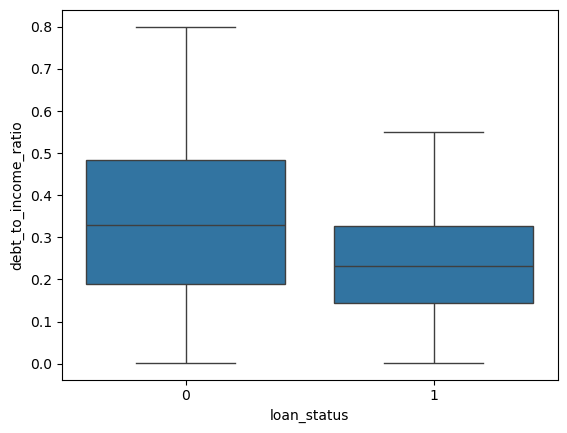

In [23]:
sns.boxplot(x='loan_status', y='debt_to_income_ratio', data=df)
plt.show()

Debt-to-income ratio exhibits a strong inverse relationship with loan approval. Rejected applicants tend to have substantially higher debt burdens relative to their income, making this feature a strong candidate for predicting loan approval.

In [26]:
df.corr(numeric_only=True)['loan_status'].sort_values(ascending=False)

loan_status                1.000000
credit_score               0.496316
age                        0.311524
credit_history_years       0.277103
years_employed             0.218875
annual_income              0.158466
savings_assets             0.094789
loan_amount               -0.025987
current_debt              -0.088494
interest_rate             -0.185179
loan_to_income_ratio      -0.193252
payment_to_income_ratio   -0.193258
derogatory_marks          -0.224735
defaults_on_file          -0.263033
debt_to_income_ratio      -0.317363
delinquencies_last_2yrs   -0.318075
Name: loan_status, dtype: float64

## Correlation Analysis

The strongest positive predictor of loan approval is credit score (0.496), indicating that applicants with better creditworthiness are significantly more likely to receive approval.

Other positively correlated features include age, credit history length, years employed, and annual income.

The strongest negative predictors are debt-to-income ratio (-0.317), delinquencies in the last two years (-0.318), defaults on file (-0.263), and derogatory marks (-0.225). These variables indicate financial risk and reduce the likelihood of loan approval.

Overall, the analysis suggests that loan approval decisions are driven primarily by creditworthiness and repayment behavior rather than the requested loan amount.

In [27]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [28]:
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(exclude='object').columns.tolist()

print(categorical_cols)
print(numerical_cols)

['occupation_status', 'product_type', 'loan_intent']
['age', 'years_employed', 'annual_income', 'credit_score', 'credit_history_years', 'savings_assets', 'current_debt', 'defaults_on_file', 'delinquencies_last_2yrs', 'derogatory_marks', 'loan_amount', 'interest_rate', 'debt_to_income_ratio', 'loan_to_income_ratio', 'payment_to_income_ratio']


In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ]
)

In [31]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [32]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(40000, 24)
(10000, 24)


In [33]:
X_train_processed

array([[-1.16399661, -0.6760893 , -0.99052623, ...,  0.        ,
         0.        ,  1.        ],
       [-0.4454386 , -0.83315887, -0.8734588 , ...,  0.        ,
         0.        ,  0.        ],
       [-0.53525835,  0.29250642,  0.63749357, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [-0.53525835,  0.1616151 , -0.37603729, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.18329966,  0.09616945,  1.39614576, ...,  1.        ,
         0.        ,  0.        ],
       [-0.2657991 ,  0.46266512, -0.5714463 , ...,  0.        ,
         0.        ,  0.        ]], shape=(40000, 24))

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


In [35]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    
    'Decision Tree': DecisionTreeClassifier(
        random_state=42
    ),
    
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),
    
    'AdaBoost': AdaBoostClassifier(
        n_estimators=100,
        random_state=42
    ),
    
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    ),
    
    'XGBoost': XGBClassifier(
        n_estimators=100,
        random_state=42,
        eval_metric='logloss'
    )
}

In [36]:
results = []

for name, model in models.items():
    
    model.fit(X_train_processed, y_train)
    
    y_pred = model.predict(X_test_processed)
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

In [37]:
results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8714,0.879307,0.887634,0.883451
1,Decision Tree,0.8722,0.886869,0.879439,0.883138
2,Random Forest,0.9144,0.919761,0.924786,0.922267
3,AdaBoost,0.9091,0.906062,0.930978,0.918351
4,Gradient Boosting,0.9204,0.917037,0.940084,0.928417
5,XGBoost,0.9338,0.935437,0.944637,0.940014


## Model Comparison

Six classification models were evaluated for loan approval prediction.

Logistic Regression and Decision Tree achieved similar accuracies of approximately 87%, establishing a strong baseline. Ensemble methods significantly improved performance.

Random Forest achieved an accuracy of 91.44%, demonstrating the effectiveness of bagging techniques. AdaBoost further improved performance to 90.91%, while Gradient Boosting achieved 92.04%.

XGBoost delivered the best overall performance with:

- Accuracy: 93.38%
- Precision: 93.54%
- Recall: 94.46%
- F1 Score: 94.00%

The results indicate that boosting-based ensemble methods are highly effective for loan approval prediction, with XGBoost emerging as the best-performing model.

In [38]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train_processed, y_train)

y_pred = xgb.predict(X_test_processed)

In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.92      0.93      4509
           1       0.94      0.94      0.94      5491

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



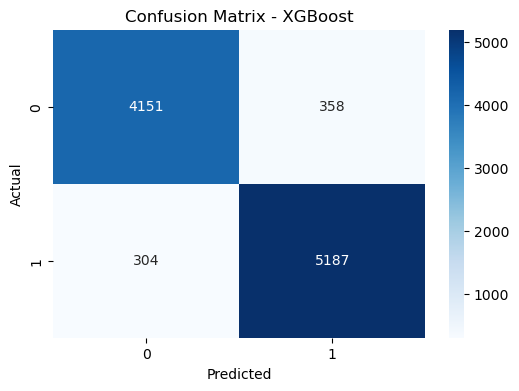

In [42]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()

In [43]:
feature_names = preprocessor.get_feature_names_out()

print(feature_names)

['num__age' 'num__years_employed' 'num__annual_income' 'num__credit_score'
 'num__credit_history_years' 'num__savings_assets' 'num__current_debt'
 'num__defaults_on_file' 'num__delinquencies_last_2yrs'
 'num__derogatory_marks' 'num__loan_amount' 'num__interest_rate'
 'num__debt_to_income_ratio' 'num__loan_to_income_ratio'
 'num__payment_to_income_ratio' 'cat__occupation_status_Self-Employed'
 'cat__occupation_status_Student' 'cat__product_type_Line of Credit'
 'cat__product_type_Personal Loan' 'cat__loan_intent_Debt Consolidation'
 'cat__loan_intent_Education' 'cat__loan_intent_Home Improvement'
 'cat__loan_intent_Medical' 'cat__loan_intent_Personal']


In [44]:
import pandas as pd

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

importance_df.head(10)

,Feature,Importance
7,num__defaults_on_file,0.153241
3,num__credit_score,0.133452
8,num__delinquencies_last_2yrs,0.086563
12,num__debt_to_income_ratio,0.085878
19,cat__loan_intent_Debt Consolidation,0.075529
23,cat__loan_intent_Personal,0.059469
20,cat__loan_intent_Education,0.056786
9,num__derogatory_marks,0.042374
13,num__loan_to_income_ratio,0.041829
4,num__credit_history_years,0.037219


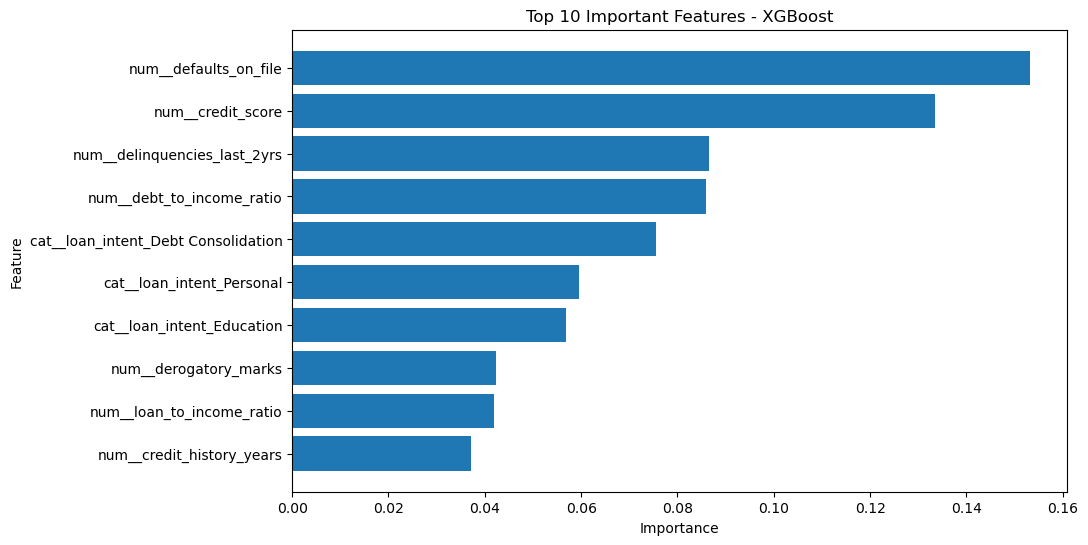

In [45]:
import matplotlib.pyplot as plt

top10 = importance_df.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10['Feature'],
    top10['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features - XGBoost")

plt.gca().invert_yaxis()

plt.show()

<Figure size 1000x800 with 0 Axes>

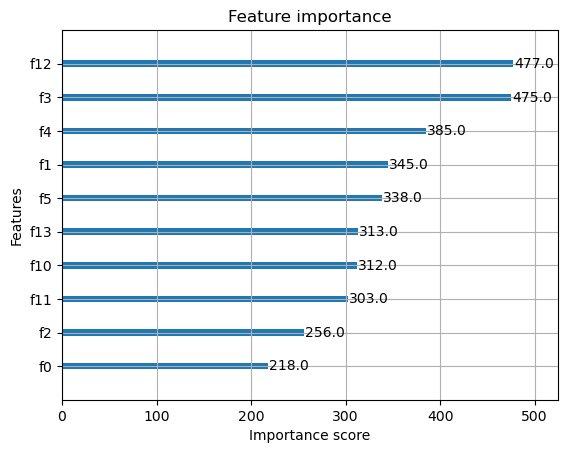

In [46]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plot_importance(
    xgb,
    max_num_features=10
)

plt.show()

In [47]:
import joblib

joblib.dump(xgb, 'xgb_model.pkl')
joblib.dump(preprocessor, 'preprocessor.pkl')

['preprocessor.pkl']